# Point Cloud to Raster via Compressed Sensing

Convert photogrammetry point cloud (x, y, z) to a regular grid raster
using L1-minimization in wavelet basis (FISTA). Preserves sharp features
and singularities for downstream 2D WTMM analysis.

In [348]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import ndimage

# ── Parameters ──
POINT_CLOUD_FILE = '/Users/amasaryk/Downloads/65LR_t40_pc_two_tilt.txt'
GRID_SPACING = 0.44          # cell size — set to 0.20 then 0.10
WAVELET = 'db4'              # wavelet for sparsity basis
WAVE_LEVEL = None            # None = max level
SUBSAMPLE_RATIO = .8     # fraction of occupied cells to keep (1.0 = use all)
LAMBDA_REG = 0.3            # sparsity regularization weight
N_ITER = 200                 # FISTA iterations
SEED = 42

# ── Stochastic mode ──
STOCHASTIC = True            # resample mask each iteration
STOCH_FRACTION = 0.2        # fraction of occupied cells per mini-batch

In [349]:
# ── Load point cloud ──
data_full = np.loadtxt(POINT_CLOUD_FILE)
print(f'Loaded {len(data_full)} points')
print(f'X: [{data_full[:,0].min():.1f}, {data_full[:,0].max():.1f}]')
print(f'Y: [{data_full[:,1].min():.1f}, {data_full[:,1].max():.1f}]')
print(f'Z: [{data_full[:,2].min():.2f}, {data_full[:,2].max():.2f}]')

Loaded 2324570 points
X: [-596.2, 21.4]
Y: [-535.9, 897.3]
Z: [-29.38, 32.02]


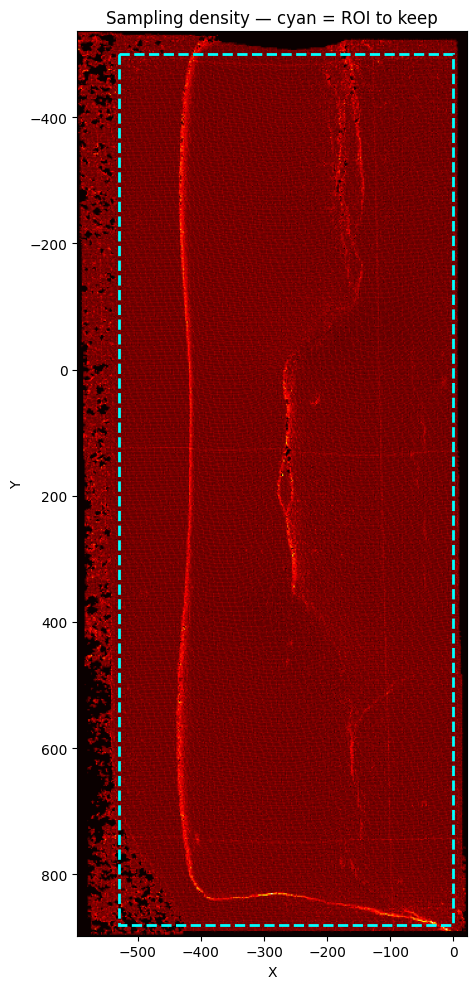

Cropped to ROI: 2042101 points
X: [-530.0, -0.0]
Y: [-500.0, 879.9]


In [350]:
# ── Manual ROI crop (re-run freely — always crops from full data) ──
ROI_XMIN, ROI_XMAX = -530, 0      # data X range to keep
ROI_YMIN, ROI_YMAX = -500, 880    # data Y range to keep

# Density map from full data
coarse_sp = 2.0
cnx = int(np.ceil((data_full[:,1].max() - data_full[:,1].min()) / coarse_sp)) + 1
cny = int(np.ceil((data_full[:,0].max() - data_full[:,0].min()) / coarse_sp)) + 1
cix = ((data_full[:,0] - data_full[:,0].min()) / coarse_sp).astype(int).clip(0, cny - 1)
ciy = ((data_full[:,1] - data_full[:,1].min()) / coarse_sp).astype(int).clip(0, cnx - 1)
density = np.zeros((cnx, cny))
np.add.at(density, (ciy, cix), 1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(density, cmap='hot', aspect='equal',
          extent=[data_full[:,0].min(), data_full[:,0].max(), data_full[:,1].max(), data_full[:,1].min()])
rect = plt.Rectangle((ROI_XMIN, ROI_YMIN), ROI_XMAX - ROI_XMIN, ROI_YMAX - ROI_YMIN,
                      linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Sampling density — cyan = ROI to keep')
plt.tight_layout()
plt.show()

# Always crop from full data
in_roi = ((data_full[:,0] >= ROI_XMIN) & (data_full[:,0] <= ROI_XMAX) &
          (data_full[:,1] >= ROI_YMIN) & (data_full[:,1] <= ROI_YMAX))
data = data_full[in_roi]
print(f'Cropped to ROI: {len(data)} points')
print(f'X: [{data[:,0].min():.1f}, {data[:,0].max():.1f}]')
print(f'Y: [{data[:,1].min():.1f}, {data[:,1].max():.1f}]')

In [351]:
# ── Compute grid + bilinear splatting ──
xmin, xmax = data[:,0].min(), data[:,0].max()
ymin, ymax = data[:,1].min(), data[:,1].max()
NY = int(np.ceil((xmax - xmin) / GRID_SPACING)) + 1
NX = int(np.ceil((ymax - ymin) / GRID_SPACING)) + 1
print(f'Grid: {NX} x {NY} = {NX*NY/1e6:.1f}M cells  (spacing={GRID_SPACING})')

fx = (data[:,0] - xmin) / GRID_SPACING
fy = (data[:,1] - ymin) / GRID_SPACING

ix0 = np.clip(np.floor(fx).astype(int), 0, NY - 2)
iy0 = np.clip(np.floor(fy).astype(int), 0, NX - 2)

wx = fx - ix0
wy = fy - iy0
z = data[:, 2]

weight_grid = np.zeros((NX, NY))
value_grid = np.zeros((NX, NY))

for diy, dy_w in [(0, 1 - wy), (1, wy)]:
    for dix, dx_w in [(0, 1 - wx), (1, wx)]:
        w = dy_w * dx_w
        np.add.at(weight_grid, (iy0 + diy, ix0 + dix), w)
        np.add.at(value_grid, (iy0 + diy, ix0 + dix), w * z)

occupied_mask = weight_grid > 0
occupied_cells = np.where(occupied_mask.ravel())[0]
occupied_z = (value_grid / np.where(weight_grid > 0, weight_grid, 1)).ravel()[occupied_cells]

cell_ids = iy0 * NY + ix0

rng = np.random.default_rng(SEED)
print(f'Occupied cells (bilinear): {len(occupied_cells)} / {NX*NY} ({100*len(occupied_cells)/(NX*NY):.1f}%)')

Grid: 3138 x 1206 = 3.8M cells  (spacing=0.44)
Occupied cells (bilinear): 3701415 / 3784428 (97.8%)


CS measurements: 2961132 / 3784428 (78.2% of grid)


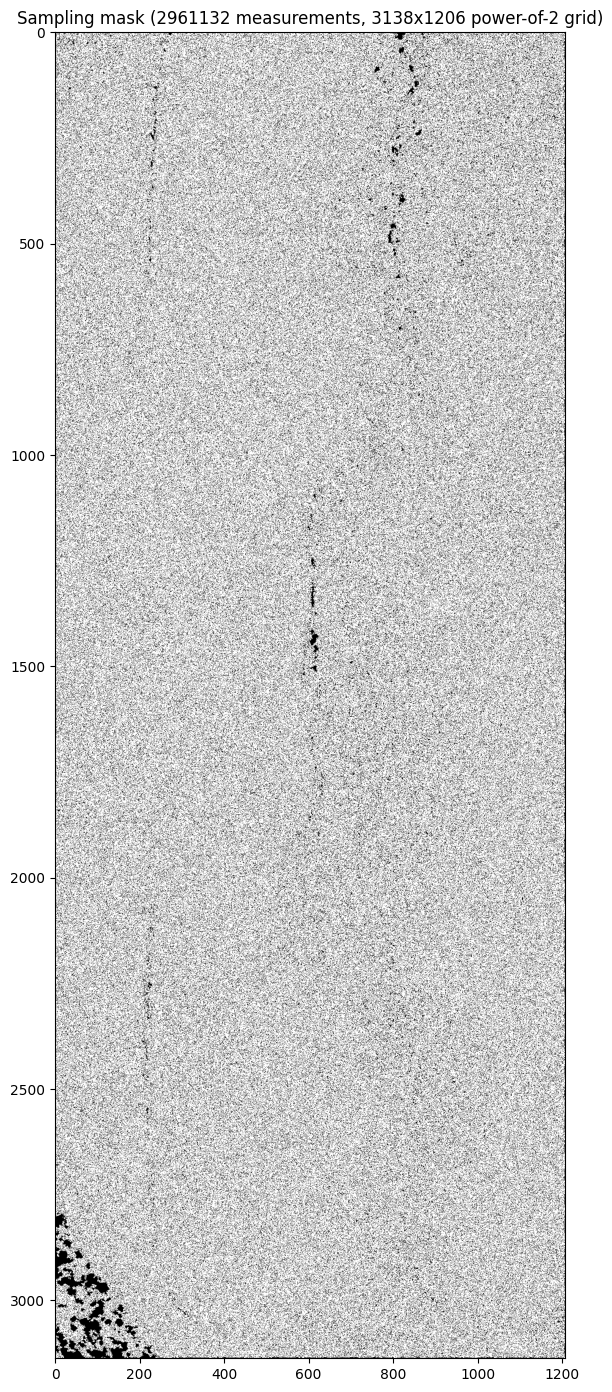

In [352]:
# ── Build sampling mask (optionally subsample) ──
if SUBSAMPLE_RATIO < 1.0:
    n_keep = int(len(occupied_cells) * SUBSAMPLE_RATIO)
    keep_idx = rng.choice(len(occupied_cells), size=n_keep, replace=False)
    keep_cells = occupied_cells[keep_idx]
    keep_z = occupied_z[keep_idx]
else:
    n_keep = len(occupied_cells)
    keep_cells = occupied_cells
    keep_z = occupied_z

mask = np.zeros(NX * NY, dtype=bool)
measurements = np.zeros(NX * NY)
mask[keep_cells] = True
measurements[keep_cells] = keep_z

mask_2d = mask.reshape(NX, NY)
meas_2d = measurements.reshape(NX, NY)

print(f'CS measurements: {n_keep} / {NX*NY} ({100*n_keep/(NX*NY):.1f}% of grid)')

fig, ax = plt.subplots(1, 1, figsize=(6, 18))
ax.imshow(mask_2d, cmap='gray', aspect='equal')
ax.set_title(f'Sampling mask ({n_keep} measurements, {NX}x{NY} power-of-2 grid)')
plt.tight_layout()
plt.show()

In [353]:
# ── Reference L1: what the bin-averaged surface looks like in wavelet domain ──
level = WAVE_LEVEL or pywt.dwt_max_level(min(NX, NY), WAVELET)
coeffs_ref = pywt.wavedec2(meas_2d, WAVELET, level=level)
ref_l1 = sum(np.sum(np.abs(c)) for detail in coeffs_ref[1:] for c in detail)
print(f'Reference L1 (measurements only): {ref_l1:.1f}')
print(f'CS reconstruction L1 should converge near this value')
print(f'Much higher → λ too low (overfitting). Much lower → λ too high (over-smoothing).')

Reference L1 (measurements only): 14794966.3
CS reconstruction L1 should converge near this value
Much higher → λ too low (overfitting). Much lower → λ too high (over-smoothing).


In [354]:
# ── FISTA with cycle-spinning + adaptive restart + stochastic mode ──

def wavelet_soft_threshold_cyclespin(image, wavelet, level, threshold, rng):
    """Cycle-spinning: random shift → DWT → soft-threshold → IDWT → unshift.
    Breaks alignment between sampling pattern and wavelet grid axes."""
    NX, NY = image.shape
    # Random shift (up to half the coarsest wavelet support)
    max_shift = 2**level
    dy = rng.integers(-max_shift, max_shift + 1)
    dx = rng.integers(-max_shift, max_shift + 1)
    
    shifted = np.roll(np.roll(image, dy, axis=0), dx, axis=1)
    
    coeffs = pywt.wavedec2(shifted, wavelet, level=level)
    new_coeffs = [coeffs[0]]
    for detail_level in coeffs[1:]:
        new_coeffs.append(
            tuple(pywt.threshold(c, threshold, mode='soft') for c in detail_level)
        )
    result = pywt.waverec2(new_coeffs, wavelet)[:NX, :NY]
    
    # Unshift
    return np.roll(np.roll(result, -dy, axis=0), -dx, axis=1)


def compute_cost(x, mask_2d, meas_2d, wavelet, level, lam):
    """Full objective: 0.5 ||M(x)-y||^2 + lam * ||Ψ(x)||_1"""
    data_fit = 0.5 * np.sum((mask_2d * (x - meas_2d))**2)
    coeffs = pywt.wavedec2(x, wavelet, level=level)
    l1 = sum(np.sum(np.abs(c)) for detail in coeffs[1:] for c in detail)
    return data_fit + lam * l1, data_fit, l1


def make_mask(occupied_cells, occupied_z, shape, rng, fraction=1.0):
    """Build mask_2d and meas_2d from a random subset of occupied cells."""
    NX, NY = shape
    n = int(len(occupied_cells) * fraction)
    idx = rng.choice(len(occupied_cells), size=n, replace=False)
    mask = np.zeros(NX * NY, dtype=bool)
    meas = np.zeros(NX * NY)
    mask[occupied_cells[idx]] = True
    meas[occupied_cells[idx]] = occupied_z[idx]
    return mask.reshape(shape), meas.reshape(shape)


def fista_cs(full_mask_2d, full_meas_2d, wavelet, level, lam, n_iter,
             stochastic=False, stoch_fraction=0.2,
             occupied_cells=None, occupied_z=None, rng=None):
    """
    FISTA with cycle-spinning, adaptive restart, optional stochastic mini-batching.
    
    Cycle spinning: each proximal step uses a random shift of the wavelet grid,
    breaking alignment between the diagonal sampling pattern and wavelet axes.
    """
    shape = full_mask_2d.shape
    step0 = 1.0
    
    x = full_meas_2d.copy()
    z = x.copy()
    t = 1.0
    prev_cost = np.inf
    n_restarts = 0
    
    costs = []
    for k in range(n_iter):
        # Pick measurement set for this iteration
        if stochastic:
            mb_mask, mb_meas = make_mask(occupied_cells, occupied_z, shape,
                                         rng, stoch_fraction)
            step = step0 / np.sqrt(1 + k)
        else:
            mb_mask, mb_meas = full_mask_2d, full_meas_2d
            step = step0
        
        # Gradient step
        residual = mb_mask * (z - mb_meas)
        grad = z - step * residual
        
        # Proximal step: cycle-spinning wavelet soft-threshold
        x_new = wavelet_soft_threshold_cyclespin(grad, wavelet, level, lam * step, rng)
        
        # Check cost on FULL measurement set for restart decision
        if k % 10 == 0:
            cost, data_fit, l1 = compute_cost(x_new, full_mask_2d, full_meas_2d,
                                               wavelet, level, lam)
            costs.append(cost)
            
            if cost > prev_cost:
                t = 1.0
                z = x.copy()
                n_restarts += 1
                if k % 50 == 0:
                    print(f'  iter {k:4d}: cost={cost:.4f} ↑ RESTART #{n_restarts}')
                continue
            
            prev_cost = cost
            if k % 50 == 0:
                print(f'  iter {k:4d}: cost={cost:.4f}  data={data_fit:.4f}  l1={l1:.1f}')
        
        # FISTA momentum
        if stochastic:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            momentum = min((t - 1) / t_new, 0.5)
            z = x_new + momentum * (x_new - x)
            t = t_new
        else:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            z = x_new + (t - 1) / t_new * (x_new - x)
            t = t_new
        
        x = x_new
    
    print(f'Total restarts: {n_restarts}')
    return x, costs


mode_str = 'stochastic' if STOCHASTIC else 'fixed-mask'
print(f'Running FISTA ({mode_str}) + cycle-spinning: {N_ITER} iters, λ={LAMBDA_REG}, wavelet={WAVELET}')
if STOCHASTIC:
    print(f'Mini-batch: {STOCH_FRACTION*100:.0f}% of occupied cells per iteration')
level = WAVE_LEVEL or pywt.dwt_max_level(min(NX, NY), WAVELET)
print(f'Wavelet decomposition level: {level}')

raster_cs, costs = fista_cs(
    mask_2d, meas_2d, WAVELET, level, LAMBDA_REG, N_ITER,
    stochastic=STOCHASTIC, stoch_fraction=STOCH_FRACTION,
    occupied_cells=occupied_cells, occupied_z=occupied_z,
    rng=np.random.default_rng(SEED + 1)
)
print('Done.')

Running FISTA (stochastic) + cycle-spinning: 200 iters, λ=0.3, wavelet=db4
Mini-batch: 20% of occupied cells per iteration
Wavelet decomposition level: 7
  iter    0: cost=3920023.5676  data=56564.2601  l1=12878197.7
  iter   50: cost=199249.5281  data=67130.0460  l1=440398.3
  iter  100: cost=122100.2851  data=59875.6892  l1=207415.3
  iter  150: cost=112596.0776  data=59751.3533  l1=176149.1
Total restarts: 2
Done.


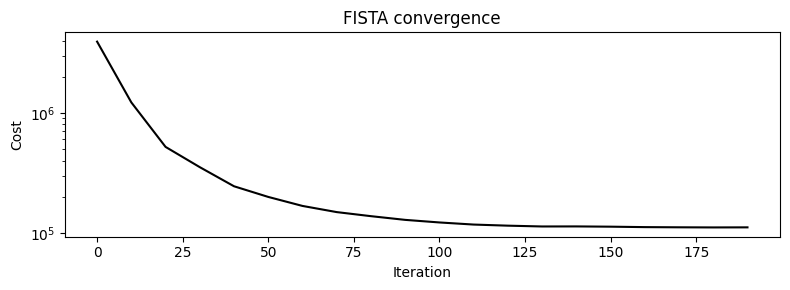

In [355]:
# ── Convergence plot ──
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(np.arange(0, N_ITER, 10), costs, 'k-')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost')
ax.set_title('FISTA convergence')
plt.tight_layout()
plt.show()

In [356]:
# ── Bin-averaged raster for comparison ──
bin_sum = np.zeros(NX * NY)
bin_count = np.zeros(NX * NY)
np.add.at(bin_sum, cell_ids, data[:, 2])
np.add.at(bin_count, cell_ids, 1)

raster_avg = np.full(NX * NY, np.nan)
valid = bin_count > 0
raster_avg[valid] = bin_sum[valid] / bin_count[valid]
raster_avg = raster_avg.reshape(NX, NY)

# Fill NaN gaps with nearest neighbor for display
nan_mask = np.isnan(raster_avg)
if nan_mask.any():
    ind = ndimage.distance_transform_edt(nan_mask, return_distances=False, return_indices=True)
    raster_avg_filled = raster_avg[tuple(ind)]
else:
    raster_avg_filled = raster_avg

print(f'Bin-averaged raster: {nan_mask.sum()} NaN cells ({100*nan_mask.sum()/(NX*NY):.1f}%)')

Bin-averaged raster: 1892785 NaN cells (50.0%)


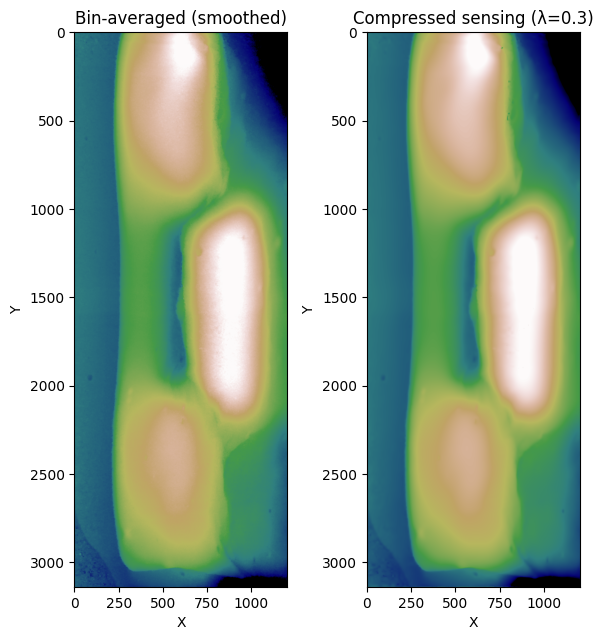

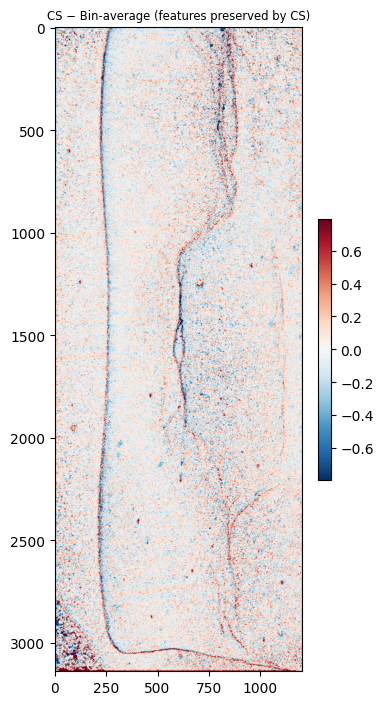

In [357]:
# ── Compare CS vs bin-average ──
vmin = np.nanpercentile(raster_avg, 2)
vmax = np.nanpercentile(raster_avg, 98)

fig, axes = plt.subplots(1, 2, figsize=(6, 18))
axes[0].imshow(raster_avg_filled, cmap='gist_earth', aspect='equal', vmin=vmin, vmax=vmax)
axes[0].set_title('Bin-averaged (smoothed)')
axes[1].imshow(raster_cs, cmap='gist_earth', aspect='equal', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Compressed sensing (λ={LAMBDA_REG})')
for ax in axes:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
plt.tight_layout()
plt.show()

# Difference
fig, ax = plt.subplots(figsize=(4, 9))
diff = raster_cs - raster_avg_filled
im = ax.imshow(diff, cmap='RdBu_r', aspect='equal', vmin=-np.std(diff)*3, vmax=np.std(diff)*3)
plt.colorbar(im, ax=ax,shrink=0.3)
ax.set_title('CS − Bin-average (features preserved by CS)', size='small')
plt.tight_layout()
plt.show()

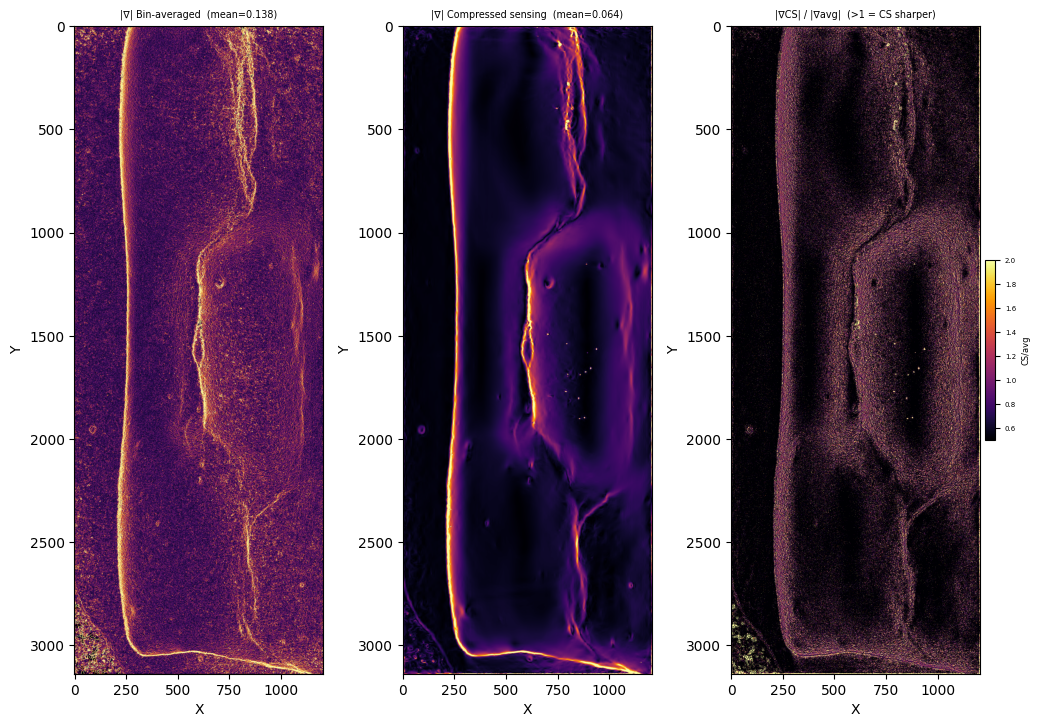

Mean gradient — CS: 0.0645, Bin-avg: 0.1380
CS/avg ratio: 0.47x


In [ ]:
# ── Edge preservation: gradient magnitude comparison ──
grad_cs_y, grad_cs_x = np.gradient(raster_cs)
grad_avg_y, grad_avg_x = np.gradient(raster_avg_filled)

grad_mag_cs = np.sqrt(grad_cs_x**2 + grad_cs_y**2)
grad_mag_avg = np.sqrt(grad_avg_x**2 + grad_avg_y**2)

vmax_grad = np.percentile(grad_mag_cs, 99)

fig, axes = plt.subplots(1, 3, figsize=(10, 18))
axes[0].imshow(grad_mag_avg, cmap='inferno', aspect='equal', vmin=0, vmax=vmax_grad)
axes[0].set_title(f'|∇| Bin-averaged  (mean={grad_mag_avg.mean():.3f})', size='x-small')
axes[1].imshow(grad_mag_cs, cmap='inferno', aspect='equal', vmin=0, vmax=vmax_grad)
axes[1].set_title(f'|∇| Compressed sensing  (mean={grad_mag_cs.mean():.3f})', size='x-small')

# Ratio: >1 means CS has sharper edges
ratio = grad_mag_cs / np.where(grad_mag_avg > 1e-6, grad_mag_avg, 1e-6)
im_ratio = axes[2].imshow(ratio, cmap='inferno', aspect='equal', vmin=0.5, vmax=2.0)
axes[2].set_title('|∇CS| / |∇avg|  (>1 = CS sharper)', size='x-small')

for ax in axes:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
plt.tight_layout()

# Colorbar in its own axes — doesn't touch the subplots
cb_h = 0.1
cax = fig.add_axes([0.99, (1 - cb_h) / 2, 0.01, cb_h])  # [left, bottom, width, height]
cb = fig.colorbar(im_ratio, cax=cax)
cb.ax.tick_params(labelsize=5)
cb.set_label('CS/avg', size=6)3

plt.show()

print(f'Mean gradient — CS: {grad_mag_cs.mean():.4f}, Bin-avg: {grad_mag_avg.mean():.4f}')
print(f'CS/avg ratio: {grad_mag_cs.mean() / grad_mag_avg.mean():.2f}x')

In [359]:
# ── Save as ASCII grid ──
tag = f'{GRID_SPACING:.2f}'.replace('.', 'p')
output_path = f'/Users/amasaryk/projects/Creep/wavelet/65LR_raster_cs_{tag}.txt'
np.savetxt(output_path, raster_cs, fmt='%.6f', delimiter=' ')
print(f'Saved {raster_cs.shape} raster to {output_path}')

# Also save the bin-averaged version for comparison
output_avg = f'/Users/amasaryk/projects/Creep/wavelet/65LR_raster_avg_{tag}.txt'
np.savetxt(output_avg, raster_avg_filled, fmt='%.6f', delimiter=' ')
print(f'Saved bin-averaged raster to {output_avg}')

Saved (3138, 1206) raster to /Users/amasaryk/projects/Creep/wavelet/65LR_raster_cs_0p44.txt
Saved bin-averaged raster to /Users/amasaryk/projects/Creep/wavelet/65LR_raster_avg_0p44.txt
